In [64]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay,
    f1_score, accuracy_score
)
import matplotlib.pyplot as plt

from IPython.display import display
import os
import joblib

В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/edce80b5bb02479085855b2334b17fc1). Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [65]:
train_df = pd.read_csv("../../data/data_kaggle_01/train.csv")
test_df = pd.read_csv("../../data/data_kaggle_01/test.csv")
sample_submission = pd.read_csv("../../data/data_kaggle_01/sample_submission.csv")

In [66]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [67]:
train_df.describe().round(2)

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.0
mean,7499.50,15691456.68,658.94,37.74,5.03,42729.79,1.59,0.79,0.49,117784.67,0.2
std,4330.27,135205.03,72.26,8.22,2.78,59727.31,0.53,0.41,0.50,45734.45,0.4
min,0.00,1581102.00,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,3749.75,15635143.00,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83058.14,0.0
50%,7499.50,15690175.00,662.00,37.00,5.00,0.00,2.00,1.00,0.00,123584.87,0.0
75%,11249.25,15757181.50,708.00,42.00,7.00,109531.02,2.00,1.00,1.00,156884.70,0.0
max,14999.00,15815690.00,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48,1.0


In [68]:
print(train_df.isnull().sum())

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [69]:
print(train_df['Exited'].value_counts(normalize=True))

Exited
0.0    0.796533
1.0    0.203467
Name: proportion, dtype: float64


In [70]:
print(train_df['Geography'].value_counts())
print(train_df['Gender'].value_counts())

Geography
France     9032
Spain      3303
Germany    2665
Name: count, dtype: int64
Gender
Male      8529
Female    6471
Name: count, dtype: int64


In [71]:
input_cols = [
    'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
    'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'
]
target_col = 'Exited'

X = train_df[input_cols]
y = train_df[target_col]

train_inputs, val_inputs, train_targets, val_targets = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Форма train_inputs: {train_inputs.shape}')
print(f'Форма val_inputs: {val_inputs.shape}')
print(f'Баланс класів train_targets:\n{train_targets.value_counts(normalize=True)}')
print(f'Баланс класів val_targets:\n{val_targets.value_counts(normalize=True)}')

Форма train_inputs: (12000, 10)
Форма val_inputs: (3000, 10)
Баланс класів train_targets:
Exited
0.0    0.7965
1.0    0.2035
Name: proportion, dtype: float64
Баланс класів val_targets:
Exited
0.0    0.796667
1.0    0.203333
Name: proportion, dtype: float64


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

Виконано вище

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [72]:
numeric_cols = train_inputs.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()

print(f"Числові колонки: {numeric_cols}")
print(f"Категоріальні колонки: {categorical_cols}")

Числові колонки: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Категоріальні колонки: ['Geography', 'Gender']


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [73]:
print(train_inputs['Geography'].unique())

['France' 'Germany' 'Spain']


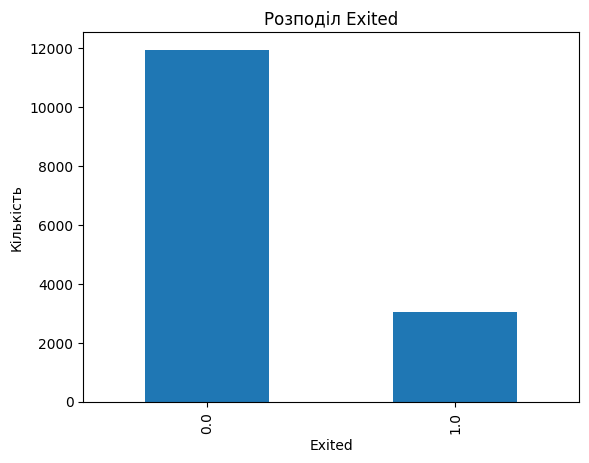

In [74]:
# 1. Target distribution
plt.figure()
train_df['Exited'].value_counts().plot(kind='bar')
plt.title('Розподіл Exited')
plt.ylabel('Кількість')
plt.show()

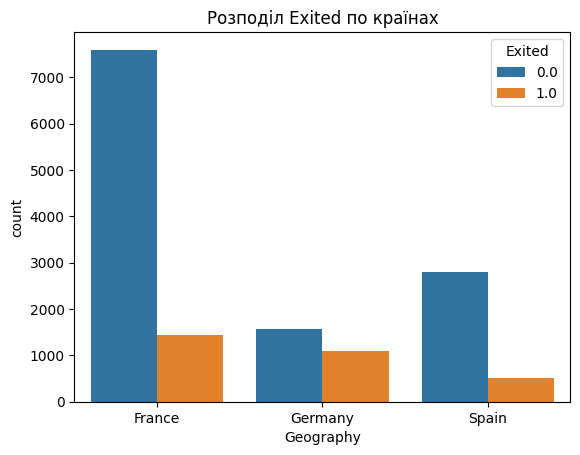

In [75]:
# 2. Geography distribution
plt.figure()
sns.countplot(x='Geography', hue='Exited', data=train_df)
plt.title('Розподіл Exited по країнах')
plt.show()

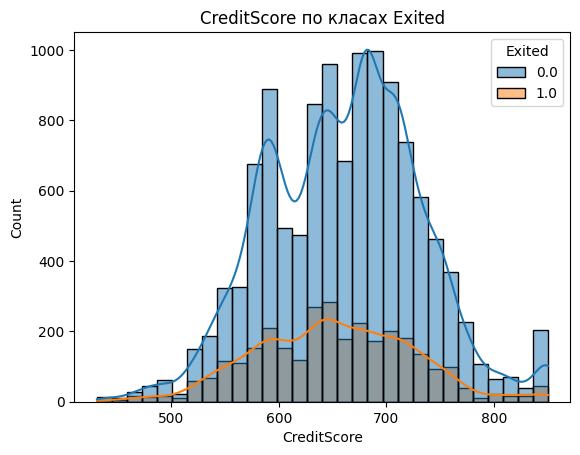

In [76]:
# 3. CreditScore vs Exited
plt.figure()
sns.histplot(data=train_df, x='CreditScore', hue='Exited', kde=True, bins=30)
plt.title('CreditScore по класах Exited')
plt.show()


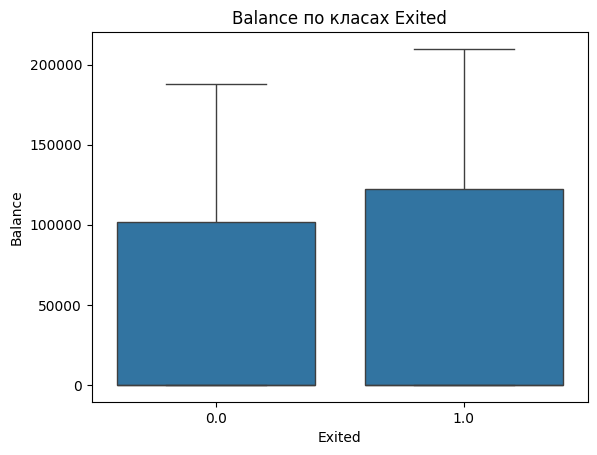

In [77]:
# 4. Boxplot Balance vs Exited
plt.figure()
sns.boxplot(x='Exited', y='Balance', data=train_df)
plt.title('Balance по класах Exited')
plt.show()

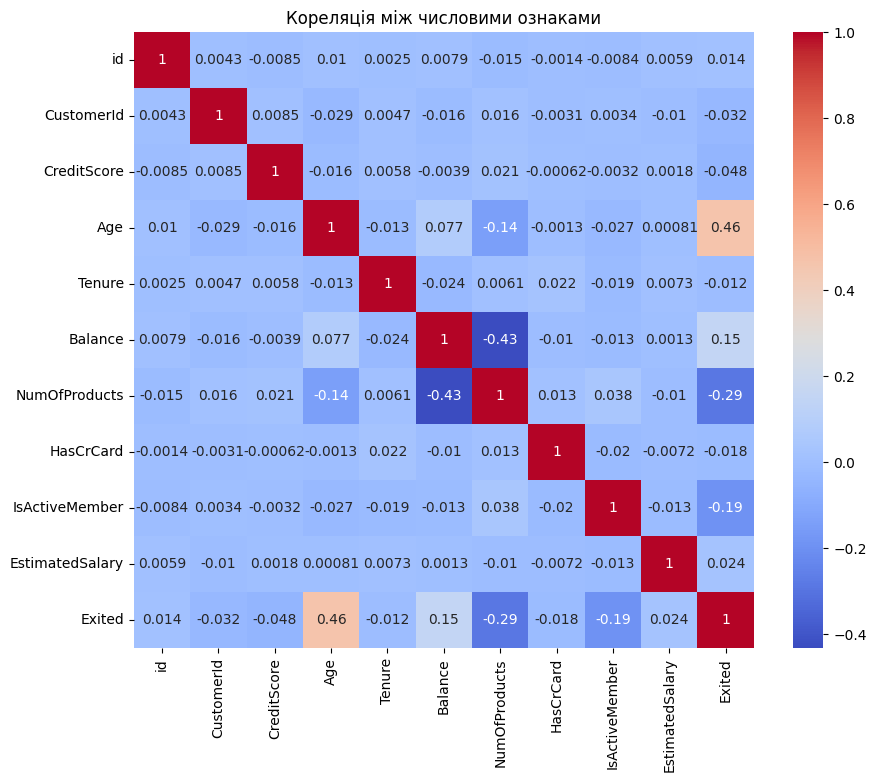

In [78]:
# 5. Heatmap correlation
corr = train_df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Кореляція між числовими ознаками')
plt.show()

1) Розподіл Exited — клас сильно незбалансований: ~80% залишились, ~20% пішли.
    - потрібен контроль за балансом (stratify), і можливо підбір метрик (F1, ROC AUC).

2) Geography vs Exited — більше відтоків у Німеччині порівняно з Францією та Іспанією.
    - географія впливає на відтік.

3) CreditScore vs Exited — сильного розриву немає, обидва класи мають схожі розподіли.
    - CreditScore не надто дискримінує класи.

4) Balance vs Exited — клієнти, що пішли, мають схожий розподіл балансу, але трохи вищі значення медіани.

5) Heatmap — вища кореляція з відтоком у:
   - Age → 0.46
   - NumOfProducts → -0.29
   - IsActiveMember → -0.19
   - Balance → 0.15

In [79]:
# Масштабування числових ознак
scaler = StandardScaler()

train_inputs_scaled = train_inputs.copy()
val_inputs_scaled = val_inputs.copy()

# Масштабування
train_inputs_scaled[numeric_cols] = scaler.fit_transform(train_inputs[numeric_cols])
val_inputs_scaled[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

# Кодування Gender (0/1)
train_inputs_scaled['Gender'] = train_inputs_scaled['Gender'].map({'Male': 1, 'Female': 0})
val_inputs_scaled['Gender'] = val_inputs_scaled['Gender'].map({'Male': 1, 'Female': 0})

# One-hot Geography
geo_train_dummies = pd.get_dummies(train_inputs_scaled['Geography'], prefix='Geography', drop_first=True)
geo_val_dummies   = pd.get_dummies(val_inputs_scaled['Geography'], prefix='Geography', drop_first=True)

train_inputs_scaled = pd.concat([train_inputs_scaled.drop(columns='Geography'), geo_train_dummies], axis=1)
val_inputs_scaled   = pd.concat([val_inputs_scaled.drop(columns='Geography'), geo_val_dummies], axis=1)

# Перевіряємо
print("train_inputs_scaled (5 рядків):")
display(train_inputs_scaled.head())

print("val_inputs_scaled (5 рядків):")
display(val_inputs_scaled.head())

train_inputs_scaled (5 рядків):


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
7180,0.320187,1,-0.944682,-1.447264,1.475464,-1.108193,0.515062,1.016977,0.569450,False,False
10393,0.347838,0,0.161227,-1.087792,2.254434,-1.108193,0.515062,-0.983306,0.603803,False,False
80,0.638166,1,-0.330288,0.350096,1.223831,0.769304,0.515062,-0.983306,1.238026,True,False
3365,0.140460,1,2.495924,-1.806736,-0.717950,0.769304,-1.941514,1.016977,-1.457116,False,True
12236,0.665816,1,-2.050591,-0.728320,-0.717950,0.769304,0.515062,1.016977,0.670629,False,False


val_inputs_scaled (5 рядків):


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
6490,0.762592,1,1.021379,-1.447264,1.214543,4.524299,0.515062,1.016977,-0.988144,True,False
3646,-0.910252,1,0.406985,-0.009376,-0.717950,0.769304,0.515062,1.016977,-1.750392,False,False
5306,0.997620,0,0.038348,-1.087792,-0.717950,0.769304,-1.941514,1.016977,-0.022404,False,False
652,0.195761,0,0.652742,-0.368848,1.881867,-1.108193,-1.941514,1.016977,-0.139723,False,False
2627,0.264887,0,-0.944682,-0.368848,-0.717950,0.769304,0.515062,-0.983306,0.563519,False,True


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [80]:
output_dir = 'processed_data'
os.makedirs(output_dir, exist_ok=True)

In [81]:
# Зберігаємо окремо
train_inputs_scaled.to_parquet(f'{output_dir}/train_inputs.parquet')
val_inputs_scaled.to_parquet(f'{output_dir}/val_inputs.parquet')

train_targets.to_frame(name='Exited').to_parquet(f'{output_dir}/train_targets.parquet')
val_targets.to_frame(name='Exited').to_parquet(f'{output_dir}/val_targets.parquet')

# Перевіряємо вміст папки
print("Збережені файли:")
print(os.listdir(output_dir))

Збережені файли:
['train_inputs.parquet', 'train_targets.parquet', 'val_inputs.parquet', 'val_targets.parquet']


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [82]:
# 1. Створюємо X_train та X_val
X_train = train_inputs_scaled
X_val = val_inputs_scaled

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, train_targets)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

Train:
Accuracy: 0.8745
F1 Score: 0.6399
ROC AUC: 0.8825

Validation:
Accuracy: 0.8697
F1 Score: 0.6390
ROC AUC: 0.8797


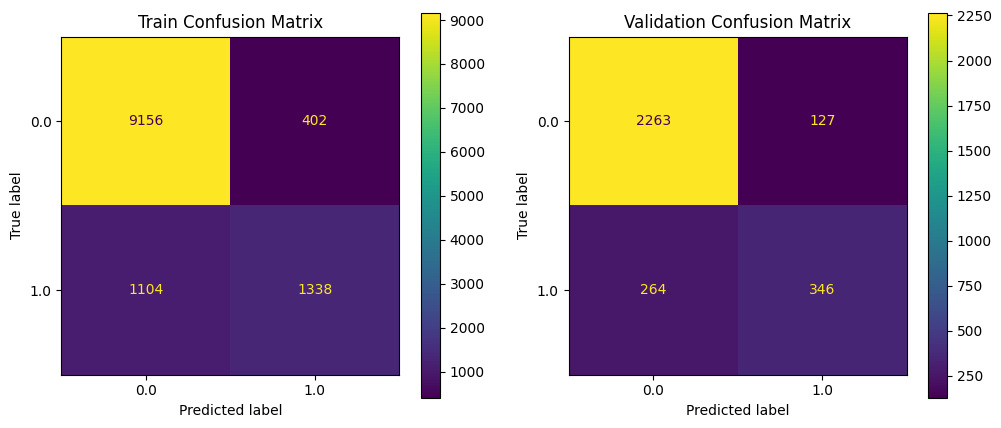

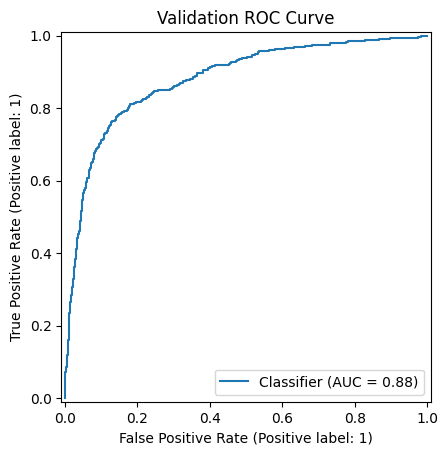

In [83]:
# --- Передбачення ---
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

# --- Метрики ---
print("Train:")
print(f"Accuracy: {accuracy_score(train_targets, train_preds):.4f}")
print(f"F1 Score: {f1_score(train_targets, train_preds):.4f}")
print(f"ROC AUC: {roc_auc_score(train_targets, train_probs):.4f}")

print("\nValidation:")
print(f"Accuracy: {accuracy_score(val_targets, val_preds):.4f}")
print(f"F1 Score: {f1_score(val_targets, val_preds):.4f}")
print(f"ROC AUC: {roc_auc_score(val_targets, val_probs):.4f}")

# --- Confusion Matrix ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(train_targets, train_preds, ax=ax[0])
ax[0].set_title("Train Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(val_targets, val_preds, ax=ax[1])
ax[1].set_title("Validation Confusion Matrix")
plt.show()

# --- ROC Curve ---
RocCurveDisplay.from_predictions(val_targets, val_probs)
plt.title("Validation ROC Curve")
plt.show()

Модель добре узагальнює: метрики на train і val майже однакові → не переобучена.

ROC AUC ≈ 0.88 — це дуже високо для класифікації в банківській сфері.

F1 > 0.63 — модель добре виявляє обидва класи.

Confusion matrix показує, що модель реально ловить клас 1 (Exited), на відміну від baseline.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [84]:

# 1. Визначимо мажоритарний клас у train
majority_class = train_targets.mode()[0]
print(f"Мажоритарний клас: {majority_class}")

# 2. Передбачаємо завжди мажоритарний клас
baseline_train_preds = [majority_class] * len(train_targets)
baseline_val_preds = [majority_class] * len(val_targets)

# 3. Accuracy
train_acc = accuracy_score(train_targets, baseline_train_preds)
val_acc = accuracy_score(val_targets, baseline_val_preds)

print(f"\nBaseline Accuracy (Train): {train_acc:.4f}")
print(f"Baseline Accuracy (Val):   {val_acc:.4f}")

Мажоритарний клас: 0.0

Baseline Accuracy (Train): 0.7965
Baseline Accuracy (Val):   0.7967


9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [85]:
# створюємо папку якщо нема
output_dir = "data_hw_2_2"
os.makedirs(output_dir, exist_ok=True)

# Збереження моделі
joblib.dump(model, os.path.join(output_dir, 'log_reg.joblib'))

# Збереження scaler
joblib.dump(scaler, os.path.join(output_dir, 'scaler.joblib'))

# Збереження даних
train_inputs_scaled.to_parquet(os.path.join(output_dir, 'train_inputs.parquet'))
val_inputs_scaled.to_parquet(os.path.join(output_dir, 'val_inputs.parquet'))
train_targets.to_frame(name='Exited').to_parquet(os.path.join(output_dir, 'train_targets.parquet'))
val_targets.to_frame(name='Exited').to_parquet(os.path.join(output_dir, 'val_targets.parquet'))


In [87]:
# Завантаження моделі
model_2 = joblib.load('data_hw_2_2/log_reg.joblib')

# Завантаження scaler
scaler = joblib.load('data_hw_2_2/scaler.joblib')

# Завантаження даних
train_inputs_loaded = pd.read_parquet('data_hw_2_2/train_inputs.parquet')
val_inputs_loaded   = pd.read_parquet('data_hw_2_2/val_inputs.parquet')
train_targets_loaded = pd.read_parquet('data_hw_2_2/train_targets.parquet')
val_targets_loaded   = pd.read_parquet('data_hw_2_2/val_targets.parquet')

In [88]:
# Передбачення на validation
val_preds_loaded = model_2.predict(val_inputs_loaded)

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print(f"Accuracy: {accuracy_score(val_targets_loaded, val_preds_loaded):.4f}")
print(f"F1 Score: {f1_score(val_targets_loaded, val_preds_loaded):.4f}")
print(f"ROC AUC: {roc_auc_score(val_targets_loaded, model_2.predict_proba(val_inputs_loaded)[:,1]):.4f}")

Accuracy: 0.8697
F1 Score: 0.6390
ROC AUC: 0.8797


10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [89]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, model, numeric_cols, input_df: pd.DataFrame):
    df_copy = input_df.copy()
    
    # Масштабування числових
    df_copy[numeric_cols] = scaler.transform(df_copy[numeric_cols])
    
    # Gender
    df_copy['Gender'] = df_copy['Gender'].map({'Male': 1, 'Female': 0})
    
    # Geography one-hot
    geo_dummies = pd.get_dummies(df_copy['Geography'], prefix='Geography', drop_first=True)
    df_copy = pd.concat([df_copy, geo_dummies], axis=1)
    df_copy.drop(columns='Geography', inplace=True)
    
    # Впорядковуємо колонки, щоб відповідали моделі
    expected_cols = model.feature_names_in_
    missing_cols = set(expected_cols) - set(df_copy.columns)
    for col in missing_cols:
        df_copy[col] = 0
    df_copy = df_copy[expected_cols]
    
    # Прогноз
    prob = model.predict_proba(df_copy)[:,1]
    return prob

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [90]:
test_raw_df = pd.read_csv("../../data/data_kaggle_01/test.csv")
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [91]:
probs = predict_raw_df(scaler, model, numeric_cols, test_raw_df)

# Додаємо як нову колонку Exited
test_raw_df['Exited'] = probs

# Перевіряємо
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.069269
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.033349
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.153780
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.198624
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.054094


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [95]:
# Підставляємо прогноз
sample_submission['Exited'] = test_raw_df['Exited']

# Перевіряємо перші 5 рядків
sample_submission.head()

,id,Exited
0,15000,0.069269
1,15001,0.033349
2,15002,0.153780
3,15003,0.198624
4,15004,0.054094


In [96]:
# Зберігаємо
sample_submission.to_csv('data_hw_2_2/submission_log_reg.csv', index=False)